<a href="https://colab.research.google.com/github/Chaidir110/PCVK_Ganjil_2025/blob/main/week5_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D-1 PERCOBAAN HISTOGRAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

<BarContainer object of 256 artists>

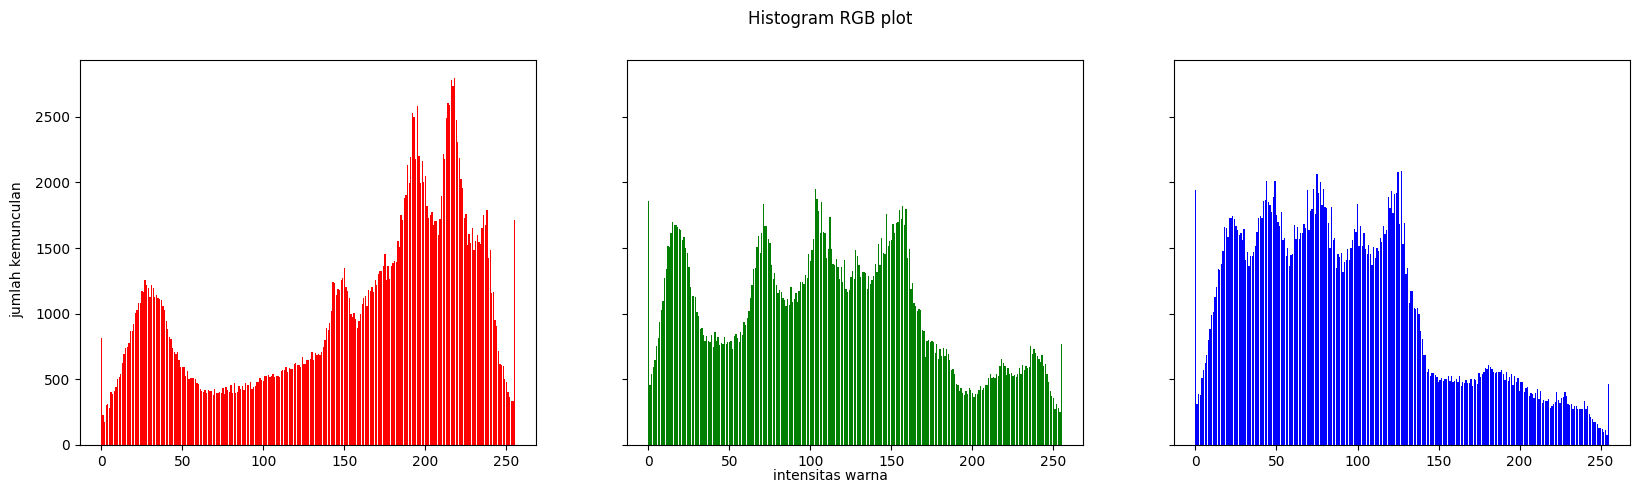

In [ ]:
#Baca histogram image manual
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(height):
  for x in range(width):
    red[img[y][x] [0]] += 1
    green[img[y][x] [1]] += 1
    blue[img[y][x] [2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'intensitas warna', ha='center')
axs[0].bar(names, red, color='r')
axs[1].bar(names, green, color='g')
axs[2].bar(names, blue, color='b')

PERTANYAAN PRAKTIKUM D1

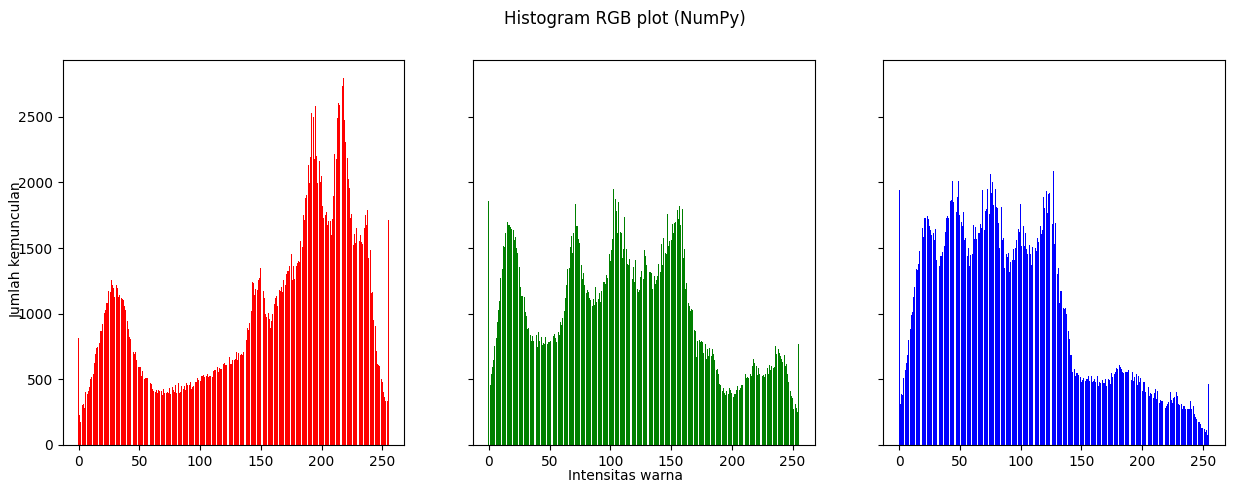

In [55]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel R, G, B
R = img[:,:,0].flatten()
G = img[:,:,1].flatten()
B = img[:,:,2].flatten()

# Hitung histogram pakai numpy
hist_r, bins_r = np.histogram(R, bins=256, range=(0,256))
hist_g, bins_g = np.histogram(G, bins=256, range=(0,256))
hist_b, bins_b = np.histogram(B, bins=256, range=(0,256))

# Plot hasil
names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[15,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (NumPy)')
fig.text(0.09, 0.5, 'Jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')
axs[0].bar(names, hist_r, color='r')
axs[1].bar(names, hist_g, color='g')
axs[2].bar(names, hist_b, color='b')
plt.show()

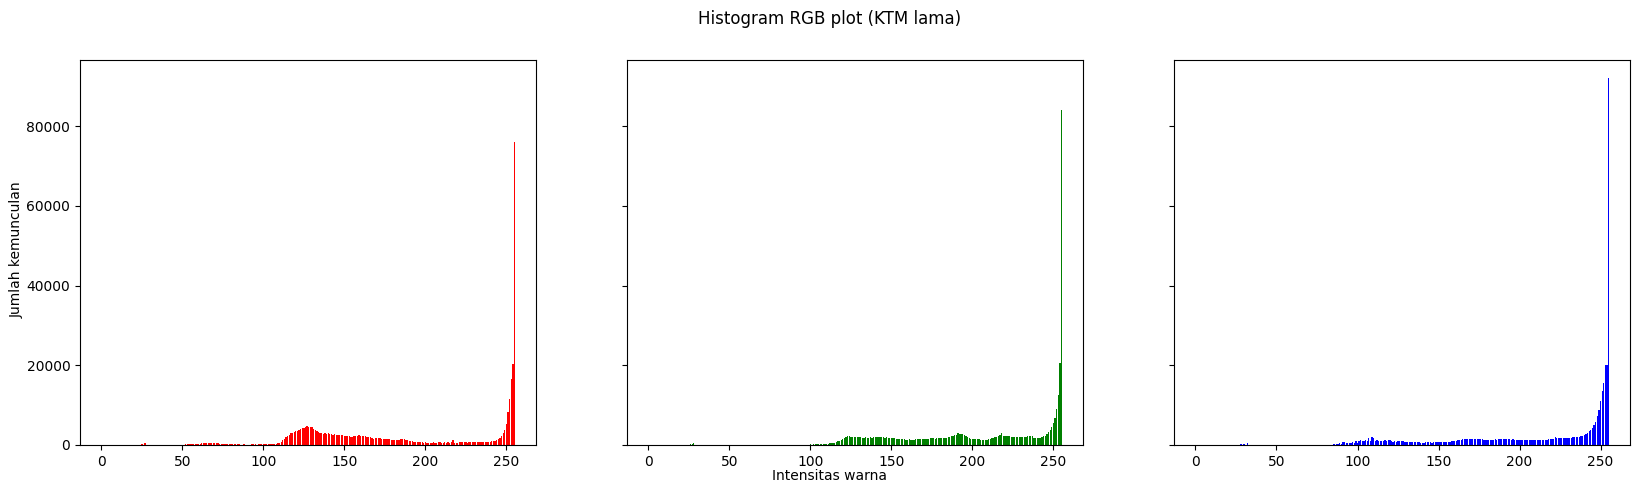

In [ ]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Ambil ukuran gambar
height, width, depth = np.shape(img)

# Array kosong untuk histogram
red = [0]*256
green = [0]*256
blue = [0]*256

# Hitung distribusi intensitas tiap kanal
for y in range(height):
    for x in range(width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)

# Plot histogram
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (KTM lama)')
fig.text(0.09, 0.5, 'Jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas warna', ha='center')
axs[0].bar(names, red, color='r')
axs[1].bar(names, green, color='g')
axs[2].bar(names, blue, color='b')
plt.show()


# D-2 PERCOBAAN HISTOGRAM EQUALIZATION

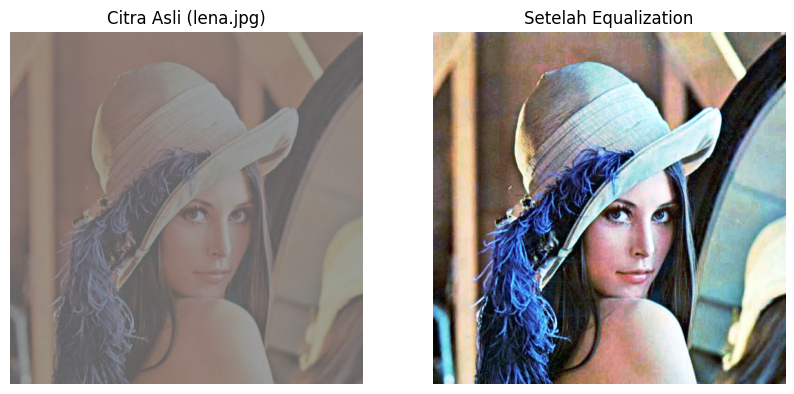

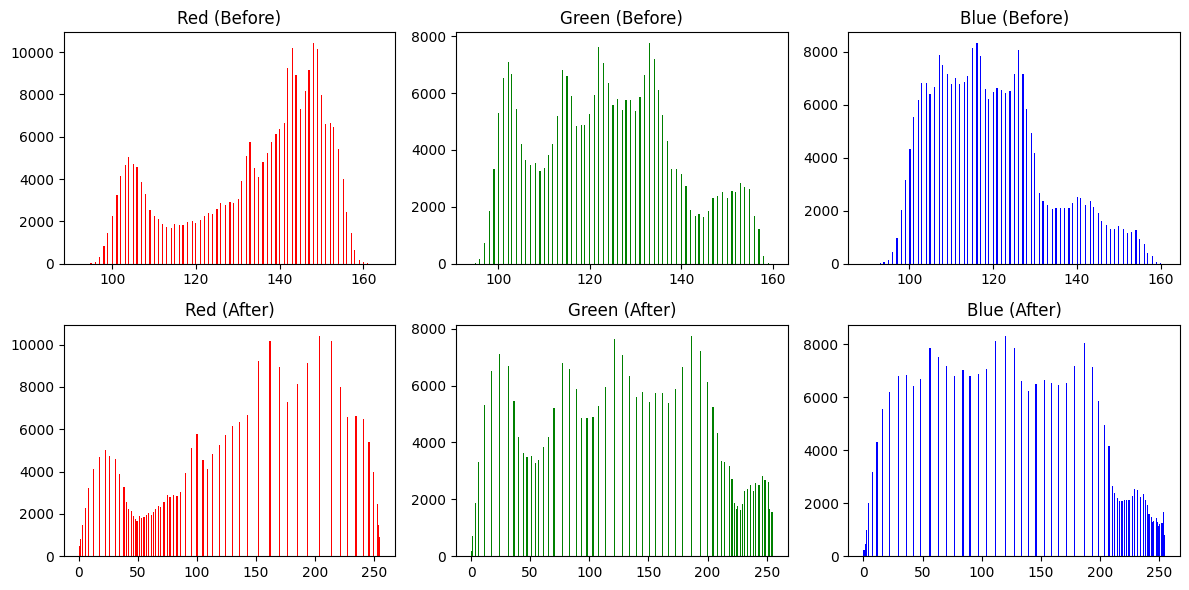

In [58]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# baca image
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Ambil dimensi
height, width, depth = img.shape
total_pixels = height * width

# Fungsi manual histogram equalization
def hist_equalization(channel):
    # Hitung histogram
    hist = np.zeros(256, dtype=int)
    for y in range(height):
        for x in range(width):
            hist[channel[y, x]] += 1

    # Hitung CDF(Cumulative Distribution Function)
    cdf = np.cumsum(hist)
    cdf_min = np.min(cdf[np.nonzero(cdf)])
    equalized_map = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255).astype('uint8')

    # Mapping pixel lama ke pixel baru
    eq_channel = equalized_map[channel]
    return eq_channel

# Pisahkan channel RGB
r, g, b = cv.split(img)

# Equalization tiap channel
r_eq = hist_equalization(r)
g_eq = hist_equalization(g)
b_eq = hist_equalization(b)

# Gabungkan kembali jadi RGB
img_eq = cv.merge([r_eq, g_eq, b_eq])

# Tampilkan citra asli vs equalization
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Citra Asli (lena.jpg)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title(f"Setelah Equalization")
plt.axis("off")

plt.show()

# Tampilkan histogram RGB sebelum & sesudah
fig, axs = plt.subplots(2, 3, figsize=(12,6))

# Histogram sebelum
axs[0,0].hist(r.ravel(), bins=256, color='red')
axs[0,0].set_title("Red (Before)")

axs[0,1].hist(g.ravel(), bins=256, color='green')
axs[0,1].set_title("Green (Before)")

axs[0,2].hist(b.ravel(), bins=256, color='blue')
axs[0,2].set_title("Blue (Before)")

# Histogram sesudah
axs[1,0].hist(r_eq.ravel(), bins=256, color='red')
axs[1,0].set_title("Red (After)")

axs[1,1].hist(g_eq.ravel(), bins=256, color='green')
axs[1,1].set_title("Green (After)")

axs[1,2].hist(b_eq.ravel(), bins=256, color='blue')
axs[1,2].set_title("Blue (After)")

plt.tight_layout()
plt.show()

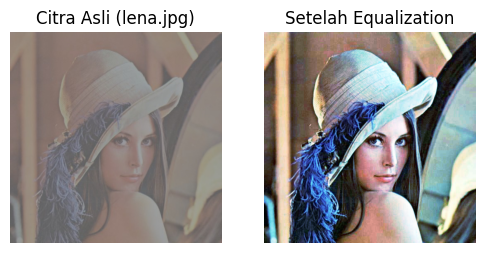

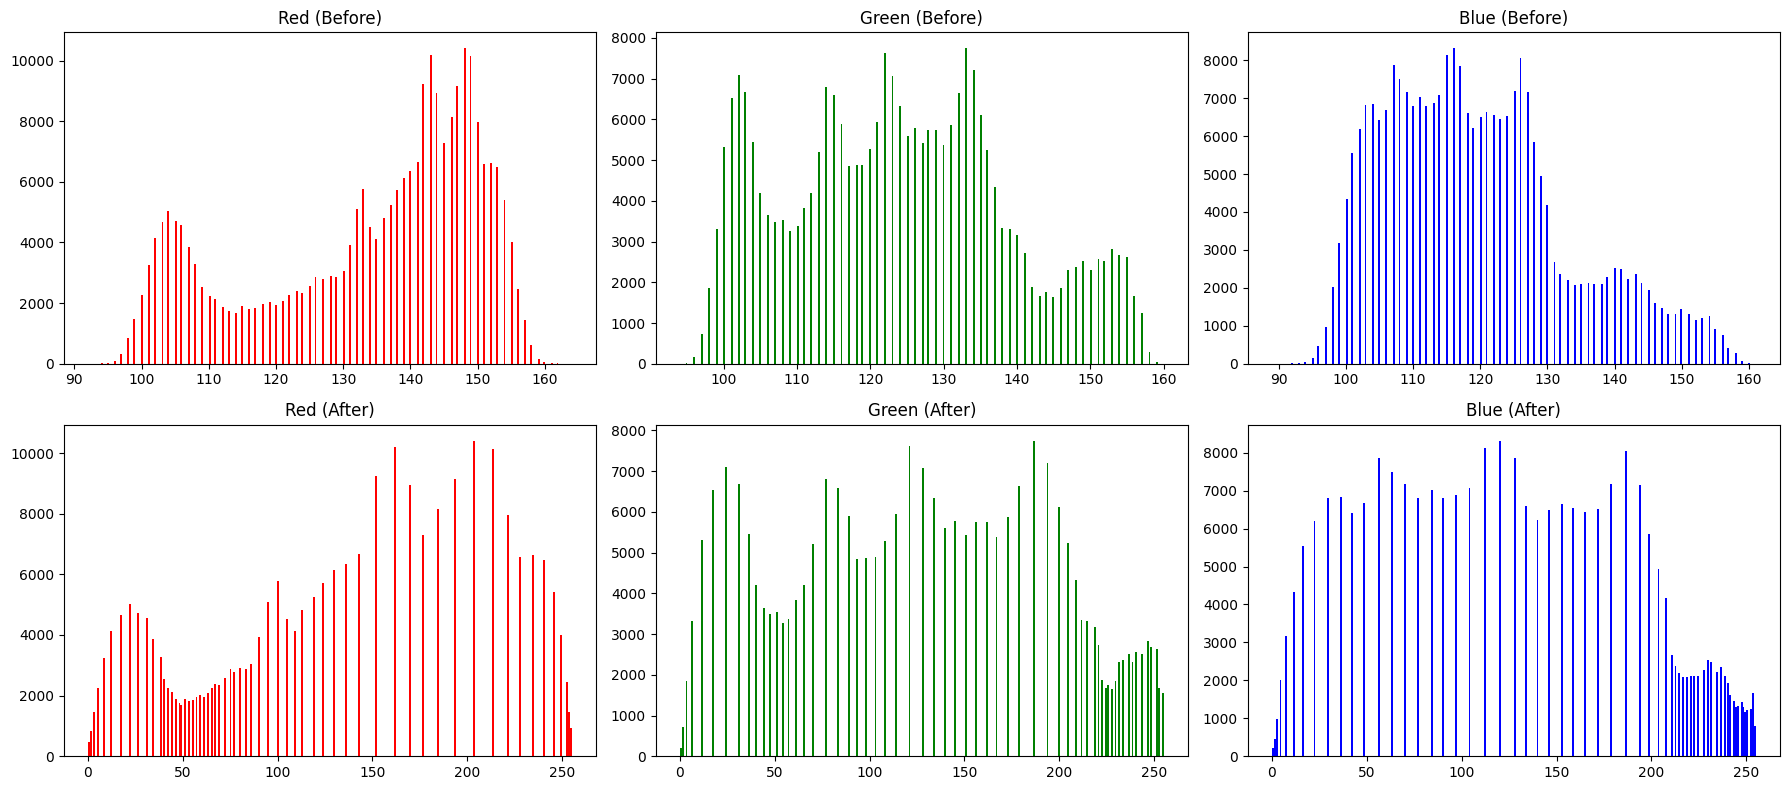

In [29]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel RGB
r, g, b = cv.split(img)

# Equalization dengan library OpenCV
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali jadi gambar RGB
img_eq = cv.merge([r_eq, g_eq, b_eq])

# Tampilkan citra asli vs equalization
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Citra Asli (lena.jpg)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title(f"Setelah Equalization")
plt.axis("off")

plt.show()

# Tampilkan histogram RGB sebelum & sesudah
fig, axs = plt.subplots(2, 3, figsize=(12,6))

# Histogram sebelum
axs[0,0].hist(r.ravel(), bins=256, color='red')
axs[0,0].set_title("Red (Before)")

axs[0,1].hist(g.ravel(), bins=256, color='green')
axs[0,1].set_title("Green (Before)")

axs[0,2].hist(b.ravel(), bins=256, color='blue')
axs[0,2].set_title("Blue (Before)")

# Histogram sesudah
axs[1,0].hist(r_eq.ravel(), bins=256, color='red')
axs[1,0].set_title("Red (After)")

axs[1,1].hist(g_eq.ravel(), bins=256, color='green')
axs[1,1].set_title("Green (After)")

axs[1,2].hist(b_eq.ravel(), bins=256, color='blue')
axs[1,2].set_title("Blue (After)")

plt.tight_layout()
plt.show()

PSNR antara lena.jpg dan hasil equalization: 17.948401139690418 dB


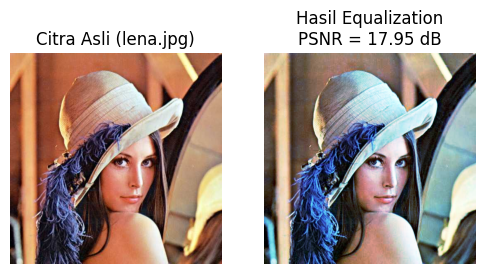

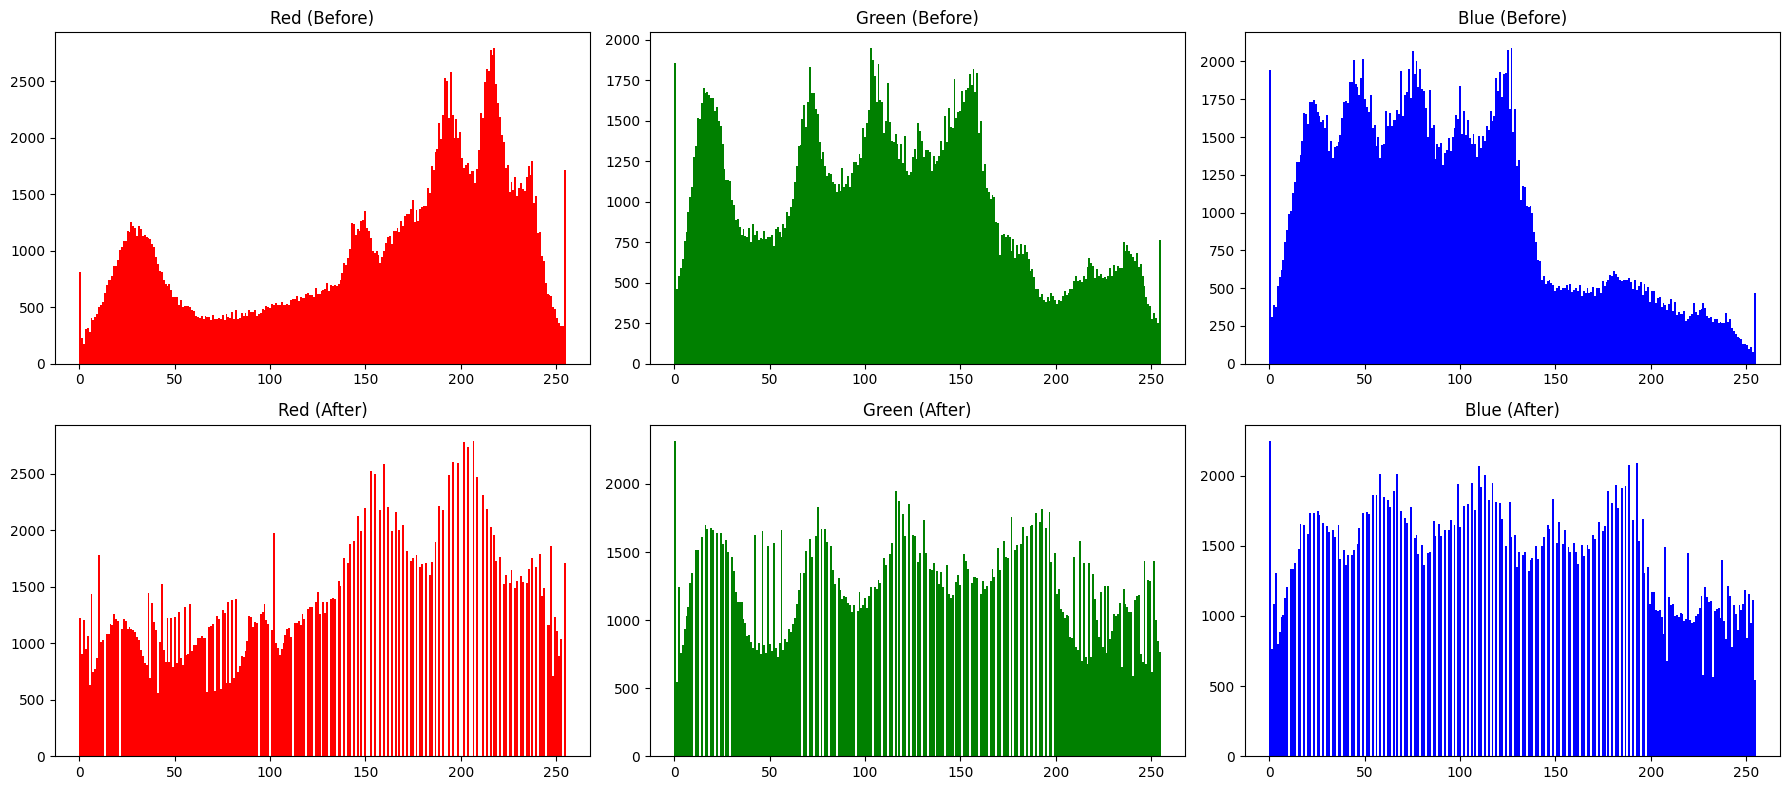

In [34]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

# Load citra asli lena.jpg
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel RGB
r, g, b = cv.split(img)

# Lakukan histogram equalization dengan OpenCV
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan jadi hasil equalization
img_eq = cv.merge([r_eq, g_eq, b_eq])

# Fungsi PSNR
def calculate_psnr(original, processed):
    mse = np.mean((original.astype(np.float32) - processed.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 10 * math.log10((max_pixel ** 2) / mse)
    return psnr

# Hitung PSNR
psnr_value = calculate_psnr(img, img_eq)
print("PSNR antara lena.jpg dan hasil equalization:", psnr_value, "dB")

# Tampilkan citra asli vs equalization
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Citra Asli (lena.jpg)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title(f"Hasil Equalization\nPSNR = {psnr_value:.2f} dB")
plt.axis("off")

plt.show()

# Tampilkan histogram RGB sebelum & sesudah
fig, axs = plt.subplots(2, 3, figsize=(18,8))

# Histogram sebelum
axs[0,0].hist(r.ravel(), bins=256, color='red')
axs[0,0].set_title("Red (Before)")

axs[0,1].hist(g.ravel(), bins=256, color='green')
axs[0,1].set_title("Green (Before)")

axs[0,2].hist(b.ravel(), bins=256, color='blue')
axs[0,2].set_title("Blue (Before)")

# Histogram sesudah
axs[1,0].hist(r_eq.ravel(), bins=256, color='red')
axs[1,0].set_title("Red (After)")

axs[1,1].hist(g_eq.ravel(), bins=256, color='green')
axs[1,1].set_title("Green (After)")

axs[1,2].hist(b_eq.ravel(), bins=256, color='blue')
axs[1,2].set_title("Blue (After)")

plt.tight_layout()
plt.show()

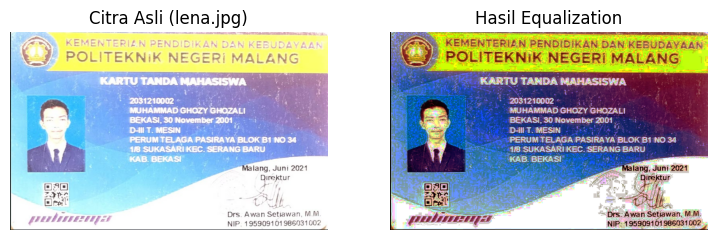

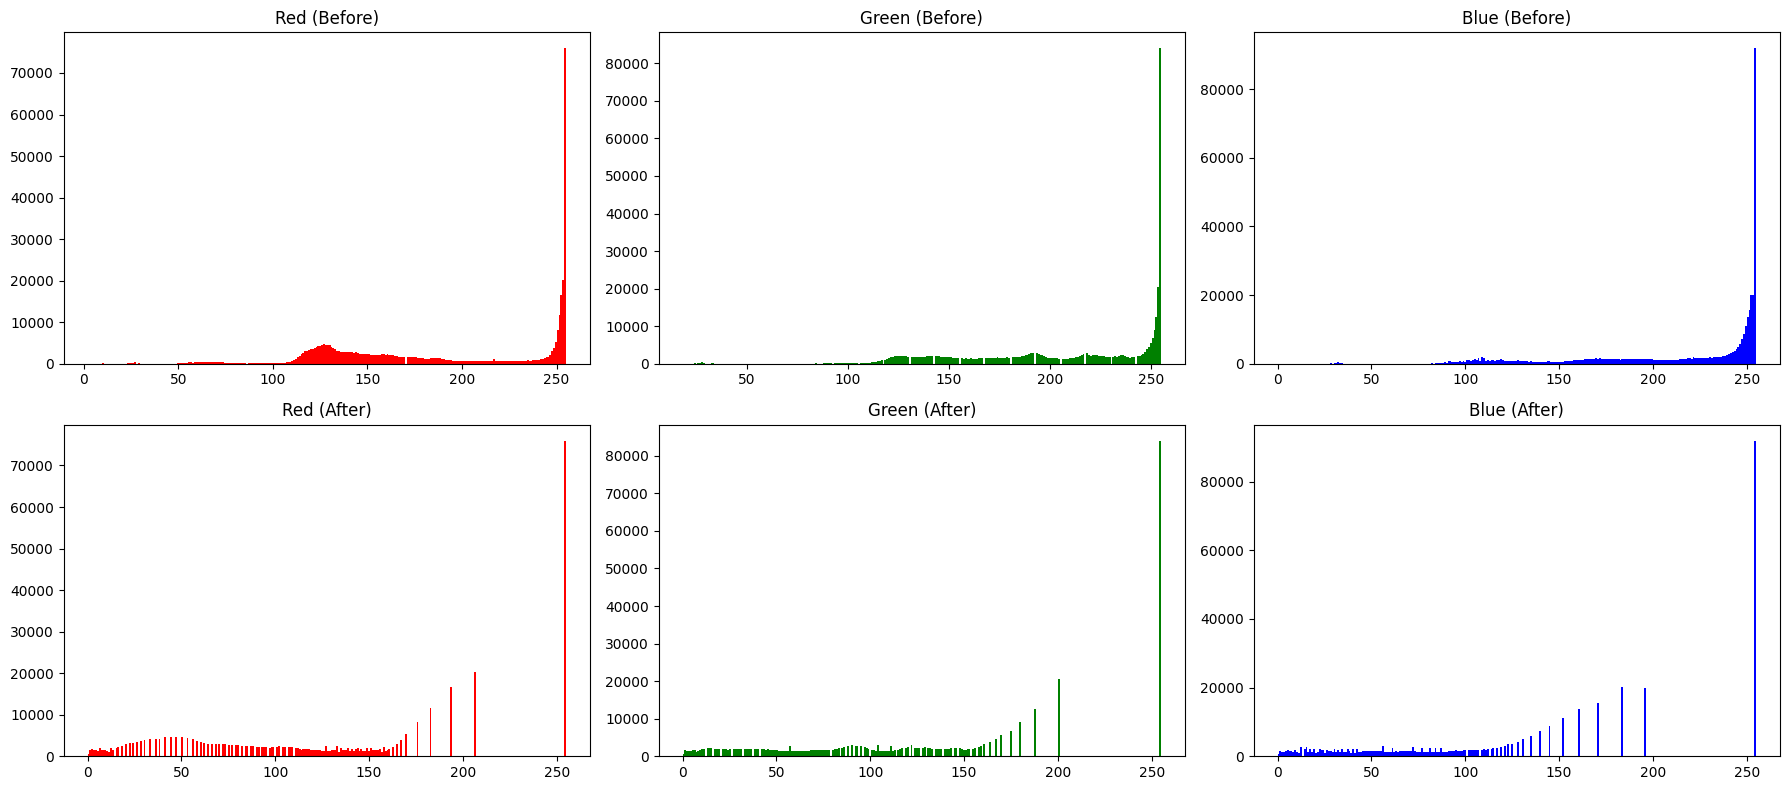

In [54]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel RGB
r, g, b = cv.split(img)

# Equalization dengan library OpenCV
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali jadi gambar RGB
img_eq = cv.merge([r_eq, g_eq, b_eq])

# Tampilkan citra asli vs equalization
plt.figure(figsize=(9,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Citra Asli (lena.jpg)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq)
plt.title(f"Hasil Equalization")
plt.axis("off")

plt.show()

# Tampilkan histogram RGB sebelum & sesudah
fig, axs = plt.subplots(2, 3, figsize=(18,8))

# Histogram sebelum
axs[0,0].hist(r.ravel(), bins=256, color='red')
axs[0,0].set_title("Red (Before)")

axs[0,1].hist(g.ravel(), bins=256, color='green')
axs[0,1].set_title("Green (Before)")

axs[0,2].hist(b.ravel(), bins=256, color='blue')
axs[0,2].set_title("Blue (Before)")

# Histogram sesudah
axs[1,0].hist(r_eq.ravel(), bins=256, color='red')
axs[1,0].set_title("Red (After)")

axs[1,1].hist(g_eq.ravel(), bins=256, color='green')
axs[1,1].set_title("Green (After)")

axs[1,2].hist(b_eq.ravel(), bins=256, color='blue')
axs[1,2].set_title("Blue (After)")

plt.tight_layout()
plt.show()

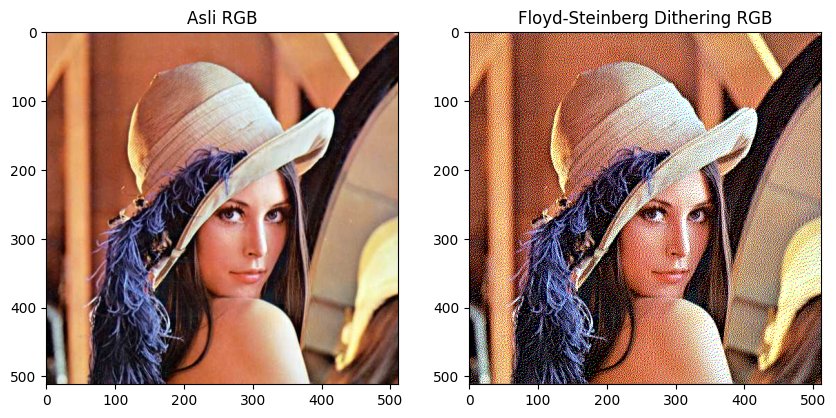

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar berwarna (RGB)
img = cv2.imread('/content/drive/MyDrive/RPL/PCVK/lena.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Konversi ke float untuk perhitungan error
dithered = img.astype(float)
rows, cols, ch = dithered.shape

for y in range(rows - 1):
    for x in range(1, cols - 1):
        for c in range(3):  # lakukan untuk R, G, B
            old_pixel = dithered[y, x, c]
            new_pixel = 0 if old_pixel < 128 else 255
            dithered[y, x, c] = new_pixel
            error = old_pixel - new_pixel

            # Sebarkan error sesuai Floyd-Steinberg
            dithered[y, x+1, c]     += error * 7/16
            dithered[y+1, x-1, c]   += error * 3/16
            dithered[y+1, x, c]     += error * 5/16
            dithered[y+1, x+1, c]   += error * 1/16

# Pastikan hasil dalam 0-255
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# Tampilkan hasil
plt.figure(figsize=(10,5))
plt.subplot(1,2,1), plt.imshow(img), plt.title("Asli RGB")
plt.subplot(1,2,2), plt.imshow(dithered), plt.title("Floyd-Steinberg Dithering RGB")
plt.show()


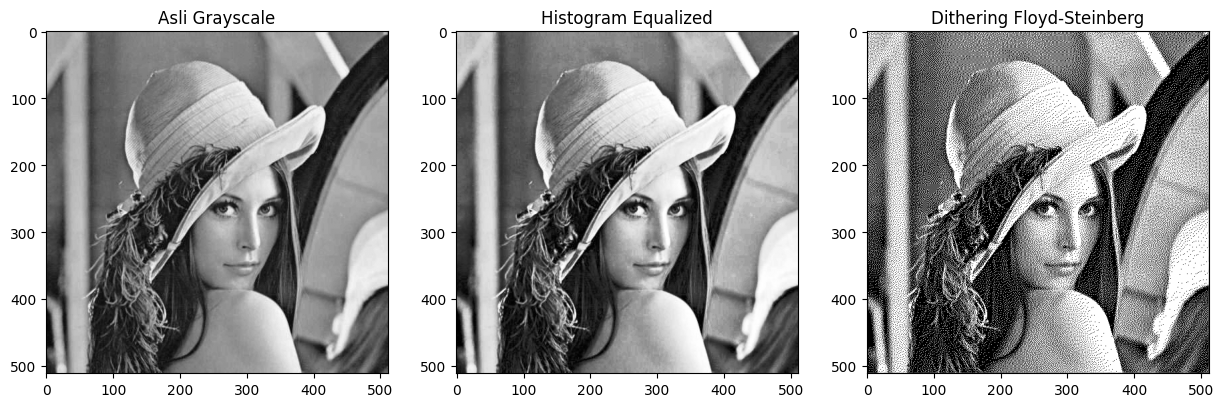

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca citra dan konversi ke grayscale
img = cv2.imread('/content/drive/MyDrive/RPL/PCVK/lena_lc.jpg', cv2.IMREAD_GRAYSCALE)

# 2. Histogram Equalization
img_eq = cv2.equalizeHist(img)

# 3. Floyd-Steinberg Dithering
dithered = img_eq.astype(float)
rows, cols = dithered.shape

for y in range(rows - 1):
    for x in range(1, cols - 1):
        old_pixel = dithered[y, x]
        new_pixel = 0 if old_pixel < 128 else 255
        dithered[y, x] = new_pixel
        error = old_pixel - new_pixel

        # Sebarkan error ke tetangga (Floyd–Steinberg kernel)
        dithered[y, x+1]     += error * 7/16
        dithered[y+1, x-1]   += error * 3/16
        dithered[y+1, x]     += error * 5/16
        dithered[y+1, x+1]   += error * 1/16

# 4. Pastikan hasil dalam range 0–255
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# 5. Tampilkan hasil
plt.figure(figsize=(15,5))
plt.subplot(1,3,1), plt.imshow(img, cmap='gray'), plt.title("Asli Grayscale")
plt.subplot(1,3,2), plt.imshow(img_eq, cmap='gray'), plt.title("Histogram Equalized")
plt.subplot(1,3,3), plt.imshow(dithered, cmap='gray'), plt.title("Dithering Floyd-Steinberg")
plt.show()


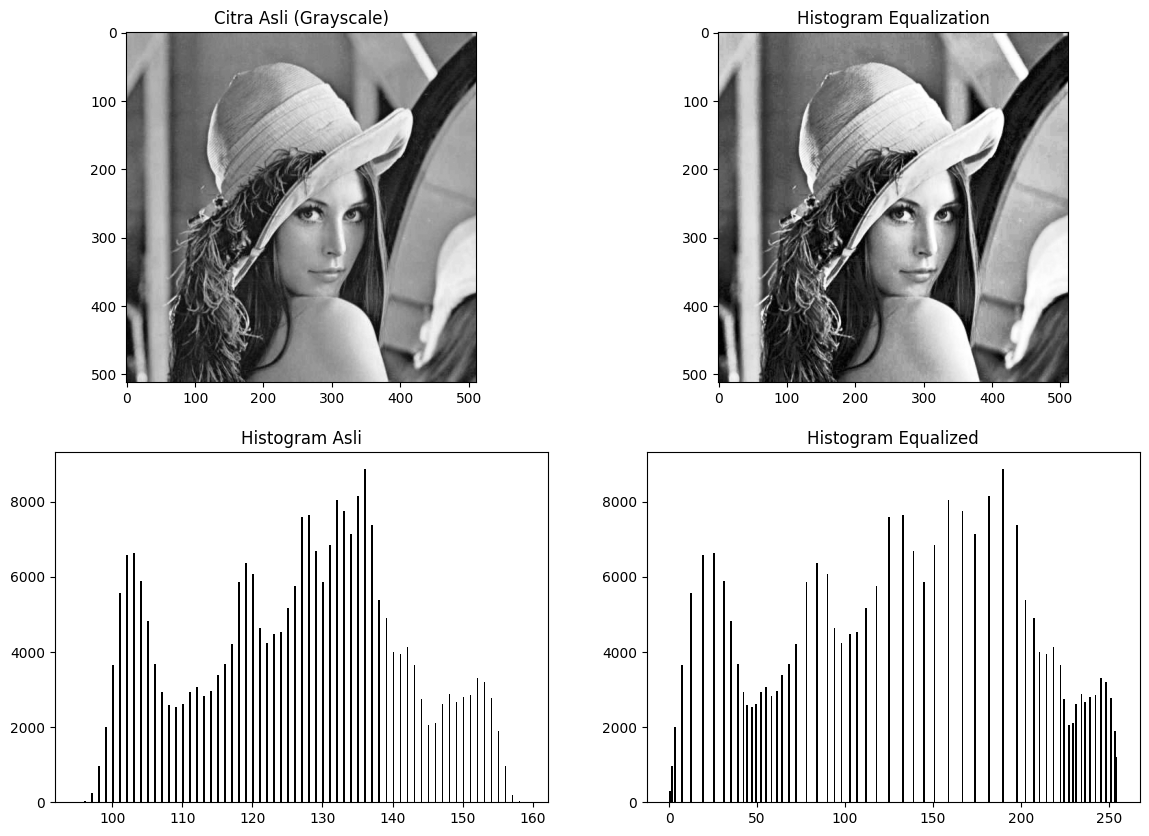

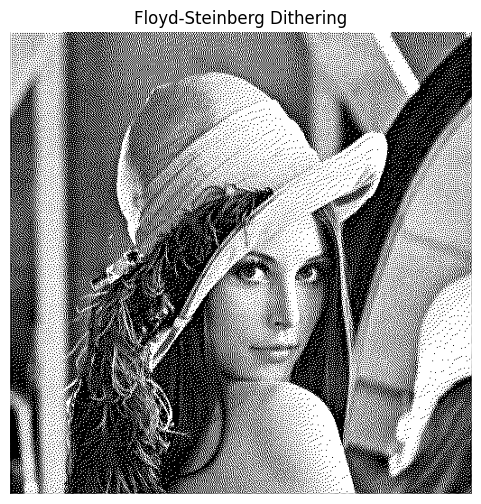

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca gambar dan konversi ke grayscale
img = cv2.imread('/content/drive/MyDrive/RPL/PCVK/lena_lc.jpg', cv2.IMREAD_GRAYSCALE)

# 2. Histogram Equalization
img_eq = cv2.equalizeHist(img)

# 3. Floyd-Steinberg Dithering pada hasil equalization
dithered = img_eq.astype(float)
rows, cols = dithered.shape

for y in range(rows - 1):
    for x in range(1, cols - 1):
        old_pixel = dithered[y, x]
        new_pixel = 0 if old_pixel < 128 else 255
        dithered[y, x] = new_pixel
        error = old_pixel - new_pixel

        dithered[y, x+1]     += error * 7/16
        dithered[y+1, x-1]   += error * 3/16
        dithered[y+1, x]     += error * 5/16
        dithered[y+1, x+1]   += error * 1/16

# 4. Konversi ke uint8
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# 5. Tampilkan hasil sesuai format
plt.figure(figsize=(14,10))

# Baris 1: Gambar asli dan equalized
plt.subplot(2,2,1), plt.imshow(img, cmap='gray'), plt.title("Citra Asli (Grayscale)")
plt.subplot(2,2,2), plt.imshow(img_eq, cmap='gray'), plt.title("Histogram Equalization")

# Baris 2: Histogram
plt.subplot(2,2,3), plt.hist(img.ravel(), bins=256, color='black'), plt.title("Histogram Asli")
plt.subplot(2,2,4), plt.hist(img_eq.ravel(), bins=256, color='black'), plt.title("Histogram Equalized")

plt.show()

# Baris 3: Hasil dithering (ditampilkan terpisah biar jelas)
plt.figure(figsize=(6,6))
plt.imshow(dithered, cmap='gray')
plt.title("Floyd-Steinberg Dithering")
plt.axis("off")
plt.show()


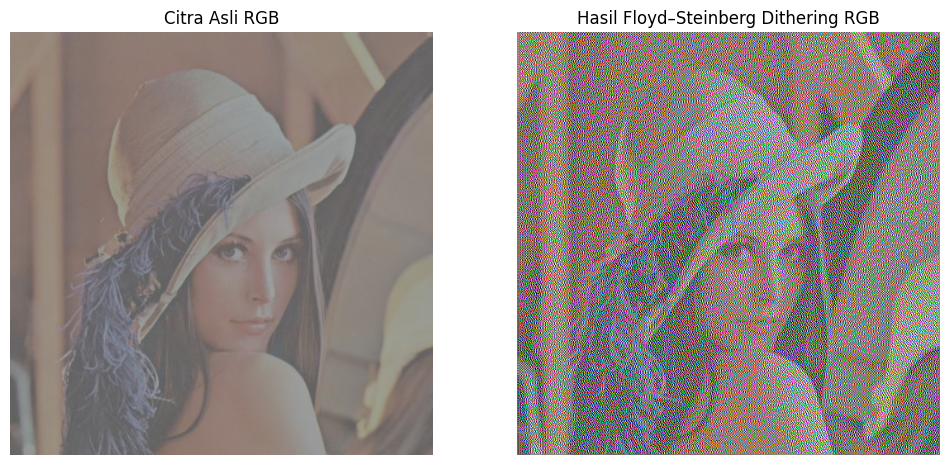

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Input image (dibaca dalam format RGB)
img = cv2.imread('/content/drive/MyDrive/RPL/PCVK/lena_lc.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Konversi ke float supaya bisa menampung nilai error (desimal)
dithered = img.astype(float)
height, width, channels = dithered.shape

# 3. Looping semua pixel (sesuai flowchart)
for y in range(height - 1):        # y dari 0 sampai tinggi-1
    for x in range(1, width - 1):  # x dari 1 sampai lebar-1
        for c in range(3):         # channel: 0=Red, 1=Green, 2=Blue
            pixelOld = dithered[y, x, c]

            # --- Hitung pixel baru berdasarkan threshold (0/255)
            pixelNew = 0 if pixelOld < 128 else 255
            dithered[y, x, c] = pixelNew

            # --- Hitung error (selisih pixel lama & baru)
            error = pixelOld - pixelNew

            # --- Sebarkan error ke pixel tetangga (Floyd–Steinberg)
            dithered[y,   x+1, c] += error * 7/16   # kanan
            dithered[y+1, x-1, c] += error * 3/16   # kiri bawah
            dithered[y+1, x,   c] += error * 5/16   # bawah
            dithered[y+1, x+1, c] += error * 1/16   # kanan bawah

# 4. Normalisasi nilai agar tetap dalam rentang 0-255
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# 5. Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1), plt.imshow(img), plt.title("Citra Asli RGB")
plt.axis("off")
plt.subplot(1,2,2), plt.imshow(dithered), plt.title("Hasil Floyd–Steinberg Dithering RGB")
plt.axis("off")
plt.show()


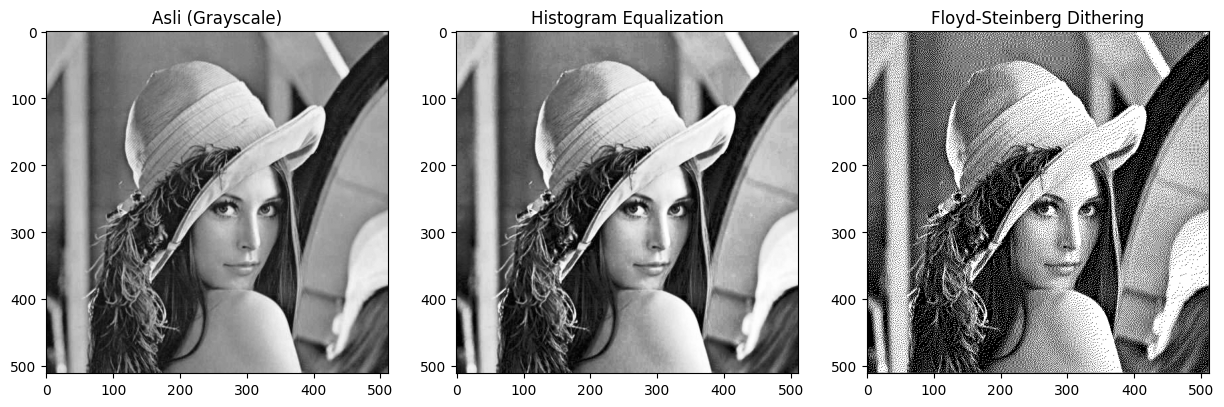

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Fungsi normalisasi pixel (sesuai flowchart z2)
def normalisasi_pixel(nilai):
    if nilai > 255:
        return 255
    elif nilai < 0:
        return 0
    else:
        return nilai

# Baca gambar (lena_lc.jpg) dan ubah ke grayscale
img = cv2.imread('/content/drive/MyDrive/RPL/PCVK/lena_lc.jpg', cv2.IMREAD_GRAYSCALE)

# Histogram Equalization
img_eq = cv2.equalizeHist(img)

# Floyd-Steinberg Dithering
rows, cols = img_eq.shape
dithered = img_eq.astype(float)

for y in range(rows - 1):
    for x in range(1, cols - 1):
        old_pixel = dithered[y, x]
        new_pixel = 0 if old_pixel < 128 else 255
        dithered[y, x] = new_pixel
        error = old_pixel - new_pixel

        # Sebarkan error sesuai Floyd-Steinberg dengan normalisasi pixel
        dithered[y, x+1]   = normalisasi_pixel(dithered[y, x+1]   + error * 7/16)
        dithered[y+1, x-1] = normalisasi_pixel(dithered[y+1, x-1] + error * 3/16)
        dithered[y+1, x]   = normalisasi_pixel(dithered[y+1, x]   + error * 5/16)
        dithered[y+1, x+1] = normalisasi_pixel(dithered[y+1, x+1] + error * 1/16)

# Pastikan hasil dalam rentang 0–255
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# Tampilkan hasil
plt.figure(figsize=(15,6))

plt.subplot(1,3,1), plt.imshow(img, cmap='gray'), plt.title("Asli (Grayscale)")
plt.subplot(1,3,2), plt.imshow(img_eq, cmap='gray'), plt.title("Histogram Equalization")
plt.subplot(1,3,3), plt.imshow(dithered, cmap='gray'), plt.title("Floyd-Steinberg Dithering")

plt.show()
